In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка данных
tr_mcc_codes = pd.read_csv('data/tr_mcc_codes.csv', sep=';')
tr_types = pd.read_csv('data/tr_types.csv', sep=';')
customers_gender_train = pd.read_csv('data/gender_train.csv')
transactions = pd.read_csv('data/transactions.csv', sep=',', nrows=1000000)

# Проверка загруженных данных
print(tr_mcc_codes.head())
print(tr_types.head())
print(customers_gender_train.head())
print(transactions.head())

   mcc_code                                    mcc_description
0       742                                Ветеринарные услуги
1      1711  Генеральные подрядчики по вентиляции, теплосна...
2      1731                        Подрядчики по электричеству
3      1799  Подрядчики, специализированная торговля — нигд...
4      2741           Разнообразные издательства/печатное дело
   tr_type                                     tr_description
0     3200  Плата за предоставление услуг посредством моби...
1     3210  Плата за предоставление отчета по счету карты ...
2     3800  Плата за обслуживание банковской карты (за пер...
3     4000            Плата за получение наличных в Сбербанке
4     4001  Плата за получение наличных в Сбербанке (в дру...
   customer_id  gender
0     10928546       1
1     69348468       1
2     61009479       0
3     74045822       0
4     27979606       1
   customer_id tr_datetime  mcc_code  tr_type    amount term_id
0     39026145  0 10:23:26      4814     1030  -

In [21]:
# Объединение данных
merged_data = transactions.merge(tr_mcc_codes, on='mcc_code', how='inner') \
.merge(tr_types, on='tr_type', how='inner') \
.merge(customers_gender_train, on='customer_id', how='left')

# Проверка количества строк после объединения
print('Количество строк после объединения:', merged_data.shape[0]) # Должно быть 999584
# Оставляем только строки с положительными значениями суммы в поле amount
positive_transactions = merged_data[merged_data['amount'] > 0].copy()

# Проверка результатов фильтрации
print('Количество положительных транзакций:', positive_transactions.shape[0])

# Убедимся, что tr_datetime является строковым типом
positive_transactions['tr_datetime'] = positive_transactions['tr_datetime'].astype(str)

# Извлечение часа из столбца tr_datetime
positive_transactions['tr_hour'] = positive_transactions['tr_datetime'].str.split(' ').str[1].str[:2]

# Проверка результатов
print(positive_transactions[['tr_datetime', 'tr_hour']].head())

Количество строк после объединения: 999584
Количество положительных транзакций: 230939
    tr_datetime tr_hour
1    1 10:19:29      10
16  10 13:00:24      13
42  23 12:02:29      12
67  37 11:36:27      11
71  38 05:45:37      05


In [22]:
# Создание категорий для amount_bucket
bins = [0, 100, 500, 1000, 5000, float('inf')]
labels = ['0-100', '101-500', '501-1000', '1001-5000', '5000+']
positive_transactions['amount_bucket'] = pd.cut(positive_transactions['amount'], bins=bins, labels=labels, right=False)

# Проверка результатов
print(positive_transactions[['amount', 'amount_bucket']].head())

       amount amount_bucket
1    56147.89         5000+
16  224591.58         5000+
42   22459.16         5000+
67   22459.16         5000+
71   96574.38         5000+


In [26]:
# Построение сводной таблицы с явным указанием observed=False
pivot_table = positive_transactions.pivot_table(
    index='tr_hour',
    columns='amount_bucket',
    values='gender',  # Используем 'gender' для вычисления средней доли женщин
    aggfunc=lambda x: x.mean(),
    fill_value=0,
    observed=False  # Указание явного значения для предотвращения FutureWarning
)

TypeError: Got both 'size' and 'fontsize', which are aliases of one another

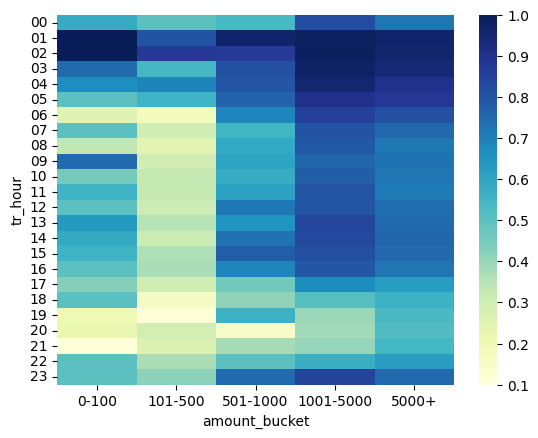

In [32]:
def plot_pivot_table(pivot_table): plt.figure(figsize=(9, 11))
sns.heatmap(pivot_table, cmap="YlGnBu", annot=True,
fmt='.3g', annot_kws={"size": 14, "fontsize": 14})
plt.xticks(fontsize=15)
plt.yticks(rotation=0, fontsize=15)
plt.xlabel('Bucket', size=18)
plt.ylabel('Hour', fontsize=18)
plt.title('Gender analysis per bucket and hour', fontsize=20)
plt.show()

In [30]:
# Анализ результатов
# 1. Проверяем долю женщин в 3 часа ночи (03) для всех "корзин"
low_spending_at_3am = pivot_table.loc["03"]
print("Доля женщин в 3 часа ночи:")
print(low_spending_at_3am)

# 2. Проверяем часы, где доля женщин превышает 80% для мелких трат (0-100)
high_female_spending = pivot_table[pivot_table['0-100'] > 0.8]
print("Часы с долей женщин > 80% для категории 0-100:")
print(high_female_spending)

Доля женщин в 3 часа ночи:
amount_bucket
0-100        0.750000
101-500      0.541667
501-1000     0.813559
1001-5000    0.973705
5000+        0.940418
Name: 03, dtype: float64
Часы с долей женщин > 80% для категории 0-100:
amount_bucket  0-100  101-500  501-1000  1001-5000     5000+
tr_hour                                                     
01               1.0    0.800  0.961538   0.980464  0.962035
02               1.0    0.875  0.866667   0.983545  0.960697
